In [46]:
#Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

!pip install xgboost

  Using cached xgboost-3.0.2-py3-none-macosx_12_0_arm64.whl (2.0 MB)

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [47]:
#Read dataset
data = pd.read_csv('data_cardiovascular_risk.csv')
#Display top 5 rows
data.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [48]:
#Check shape
data.shape

(3390, 17)

In [49]:
#Check dataypes of features
data.dtypes

id                   int64
age                  int64
education          float64
sex                 object
is_smoking          object
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [50]:
#Check for null values in the features
data.isnull().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

In [51]:
#check class imbalance
data['TenYearCHD'].value_counts()

TenYearCHD
0    2879
1     511
Name: count, dtype: int64

In [52]:
#Check statistics
data.describe()

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.000000,3390.000000,3303.000000,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
mean,1694.500000,49.542183,1.970936,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,978.753033,8.592878,1.019081,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,847.250000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,1694.500000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,2541.750000,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000
max,3389.000000,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.00000,142.500000,56.800000,143.000000,394.000000,1.000000


# Exploratory Data Analysis (EDA)

In [53]:
#drop id column
data.drop('id',axis=1,inplace=True)

<Axes: >

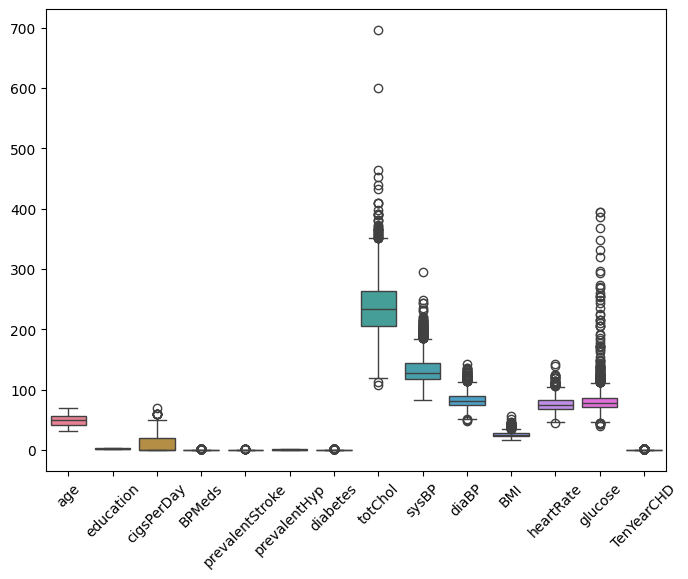

In [54]:
#Boxplot
plt.figure(figsize=(8,6))
plt.xticks(rotation = 45)
sns.boxplot(data)

<Axes: xlabel='age', ylabel='Count'>

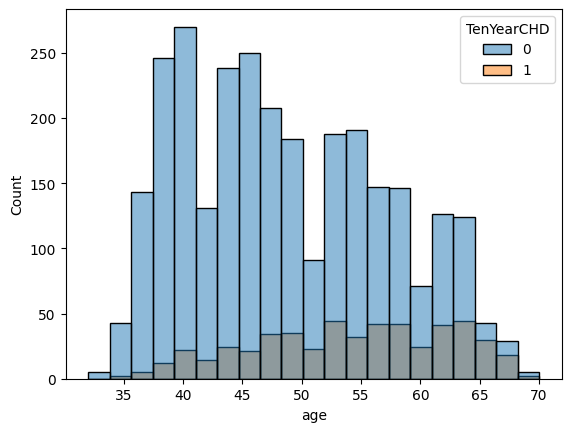

In [55]:
#does age affect chances of developing a heart disease
sns.histplot(x = 'age',hue = 'TenYearCHD',data = data)

In [56]:
data['age'].min(),data['age'].max(), data['age'].mean()

(np.int64(32), np.int64(70), np.float64(49.54218289085546))

In [57]:
# #creating age categories using binning 
# def age_category(x):
    
#     if x > 30 and x <=45:
#         return 'Adult'
#     elif x > 45 and x <= 60:
#         return 'Middle-Aged'
#     else:
#         return 'Old'
# data['age_category'] = data['age'].apply(age_category)

In [58]:
# #TenYearCHD as compared to age buckets
# sns.countplot(x = 'age_category',hue='TenYearCHD',data = data)

In [59]:
#Unique values in education column
data['education'].unique()

array([ 2.,  4.,  1.,  3., nan])

In [60]:
#Replace null values in education column with mode
data['education'] = np.where(data['education'].isnull(),data['education'].mode(),data['education'])

In [61]:
#Replace null values in cigsperday, totChol, BMI, heartRate, glucose column with median
data['cigsPerDay'] = np.where(data['cigsPerDay'].isnull(),data['cigsPerDay'].median(),data['cigsPerDay'])
data['totChol'] = np.where(data['totChol'].isnull(),data['totChol'].median(),data['totChol'])
data['BMI'] = np.where(data['BMI'].isnull(),data['BMI'].median(),data['BMI'])
data['heartRate'] = np.where(data['heartRate'].isnull(),data['heartRate'].median(),data['heartRate'])
data['glucose'] = np.where(data['glucose'].isnull(),data['glucose'].median(),data['glucose'])

In [62]:
#Replace null values in BPMeds column with mode
data['BPMeds'] = np.where(data['BPMeds'].isnull(),data['BPMeds'].mode(),data['BPMeds'])

In [63]:
#Convert sex and is_smoking columns to binary encoded labels
data['sex'] = np.where(data['sex']=='M',1,0)
data['is_smoking'] = np.where(data['is_smoking']=='YES',1,0)

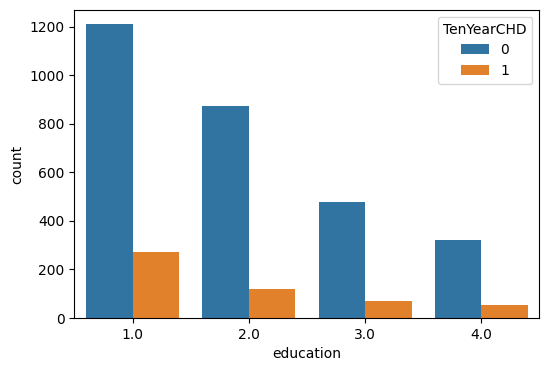

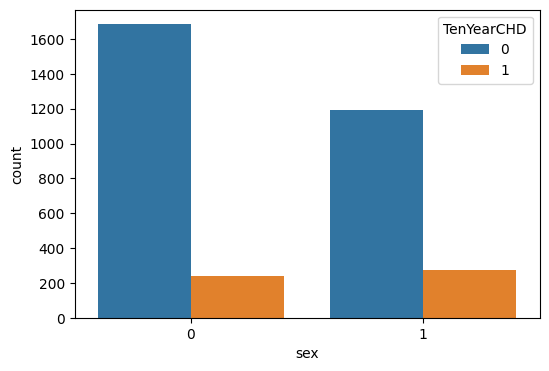

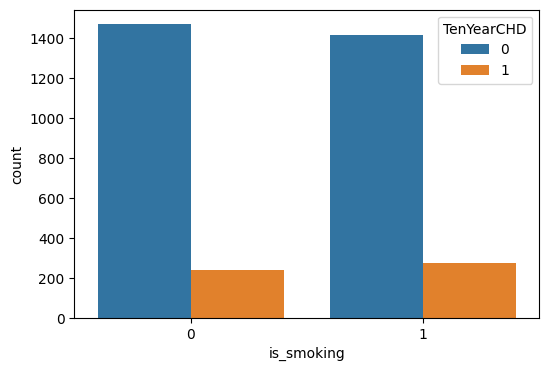

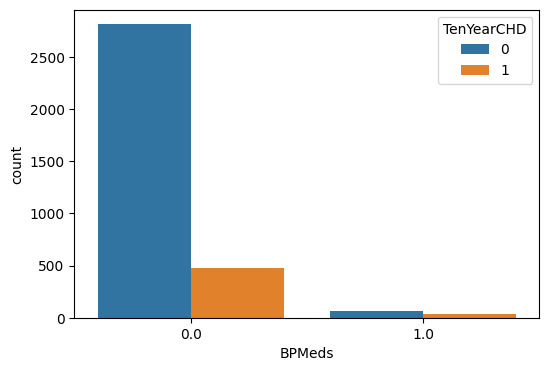

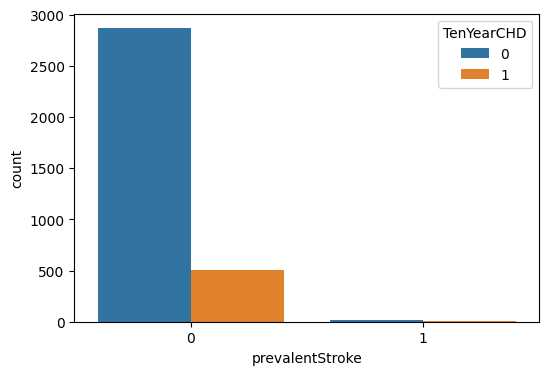

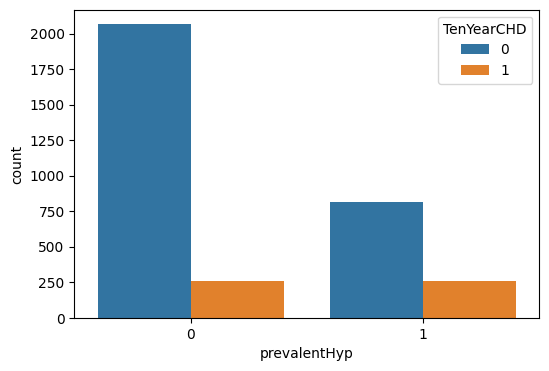

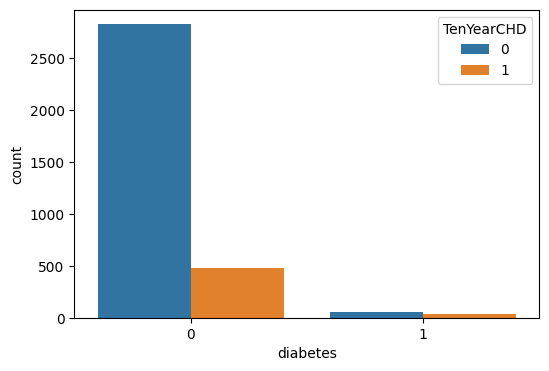

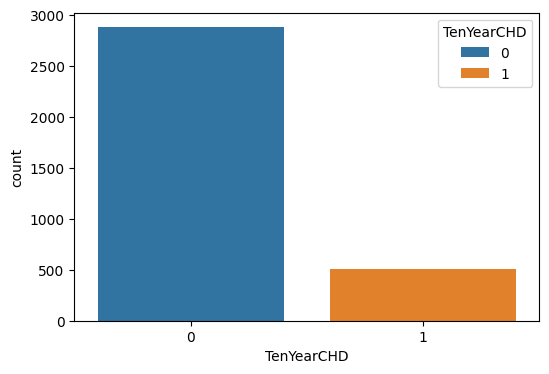

In [64]:
#analyze relationship between categorical variables and heart disease
categorical_df = data.loc[:,['education','sex','is_smoking','BPMeds','prevalentStroke','prevalentHyp','diabetes','TenYearCHD']]

for i in categorical_df:
    plt.figure(figsize=(6,4))
    sns.countplot(x = i, hue = 'TenYearCHD',data = categorical_df)
    plt.show()

In [65]:
#Check for class imbalance in target variable
print(f"People with heart disease: {data['TenYearCHD'].value_counts()[1]}")
print(f"People without heart disease: {data['TenYearCHD'].value_counts()[0]}")

People with heart disease: 511
People without heart disease: 2879


<Axes: >

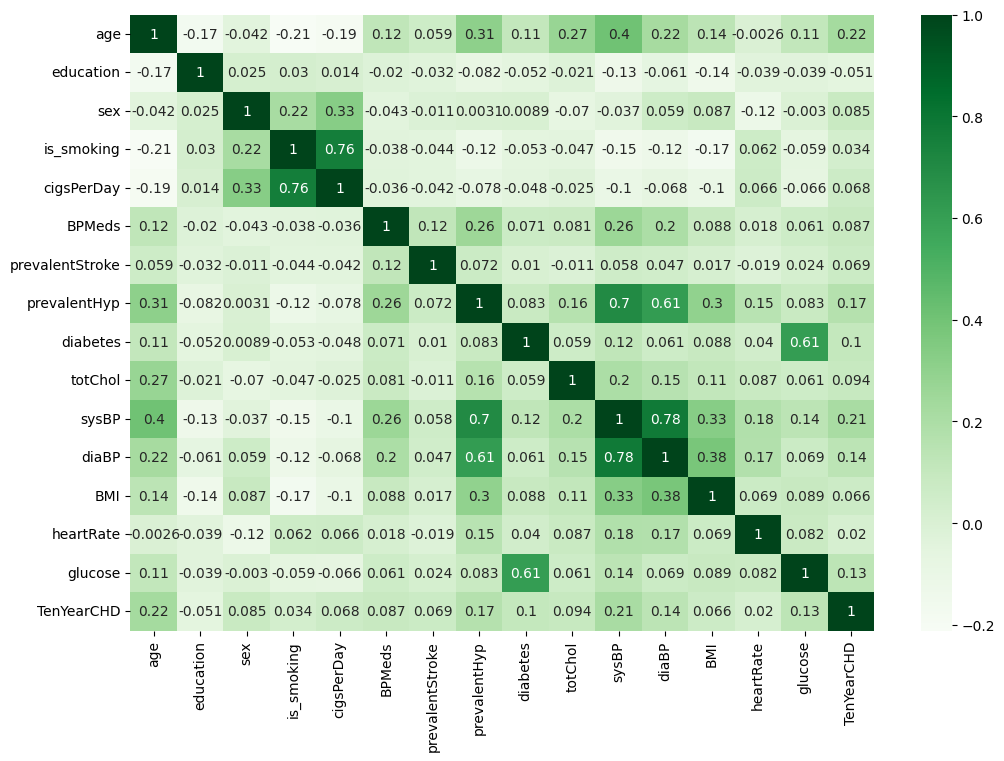

In [66]:
#Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, cmap='Greens')

In [67]:
#both the is_smoking and cigsPerDay column give the same information for people who do not smoke
data[data['is_smoking']==0]

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1,36,4.0,1,0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
5,61,3.0,0,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1
6,61,1.0,1,0,0.0,0.0,0,1,0,238.0,232.0,136.0,24.83,75.0,79.0,0
9,55,2.0,0,0,0.0,0.0,0,1,0,326.0,144.0,81.0,25.71,85.0,78.0,0
10,61,1.0,0,0,0.0,0.0,0,1,0,234.0,185.0,121.0,35.22,80.0,78.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3384,61,1.0,0,0,0.0,0.0,0,1,0,217.0,182.0,86.0,26.98,105.0,113.0,0
3385,60,1.0,0,0,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,0,0,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3388,60,1.0,1,0,0.0,0.0,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0


# Feature Engineering

In [68]:
#drop the is_smoking column as it does not add any unique information to the model
# data.drop('is_smoking',axis=1,inplace=True)

In [69]:
#create smoking intensity column
data['smoking_intensity'] = data['is_smoking'] * data['cigsPerDay']
data.head()

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,smoking_intensity
0,64,2.0,0,1,3.0,0.0,0,0,0,221.0,148.0,85.0,25.38,90.0,80.0,1,3.0
1,36,4.0,1,0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,0.0
2,46,1.0,0,1,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,10.0
3,50,1.0,1,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,20.0
4,64,1.0,0,1,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,30.0


In [70]:
#create pulse pressure column
data['pulse_pressure'] = data['sysBP'] - data['diaBP']

In [71]:
# #create a new feature MAP(Mean Arterial Pressure) using both sysBP and diaBP to resolve multicollinearity
# data['MAP'] = round((data['sysBP'] + (2 * data['diaBP']))/3,1)
# data.head()

In [72]:
# #drop sysBP and diaBP columns
# data.drop(['sysBP','diaBP'],axis=1,inplace=True)
# data.head()

In [73]:
#create column indicating cholesterol to age ratio
data['chol_age_ratio'] = data['totChol'] / data['age']

In [74]:
# Overweight and high blood pressure often co-occur.
data['bmi_sysbp_interaction'] = data['BMI'] * data['sysBP']


In [75]:
#Binary Flags for High Risk Thresholds
data['high_glucose'] = (data['glucose'] > 126).astype(int)  # possible diabetes
data['high_chol'] = (data['totChol'] > 240).astype(int)
data['obese'] = (data['BMI'] > 30).astype(int)


In [76]:
data['age_group'] = pd.cut(data['age'], bins=[0, 40, 50, 60, 70, 100], labels=False)
data.head()

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,glucose,TenYearCHD,smoking_intensity,pulse_pressure,chol_age_ratio,bmi_sysbp_interaction,high_glucose,high_chol,obese,age_group
0,64,2.0,0,1,3.0,0.0,0,0,0,221.0,...,80.0,1,3.0,63.0,3.453125,3756.24,0,0,0,3
1,36,4.0,1,0,0.0,0.0,0,1,0,212.0,...,75.0,0,0.0,70.0,5.888889,5001.36,0,0,0,0
2,46,1.0,0,1,10.0,0.0,0,0,0,250.0,...,94.0,0,10.0,45.0,5.434783,2360.60,0,1,0,1
3,50,1.0,1,1,20.0,0.0,0,1,0,233.0,...,94.0,1,20.0,70.0,4.660000,4465.08,0,0,0,1
4,64,1.0,0,1,30.0,0.0,0,0,0,241.0,...,77.0,0,30.0,51.5,3.765625,3606.33,0,1,0,3


<Axes: >

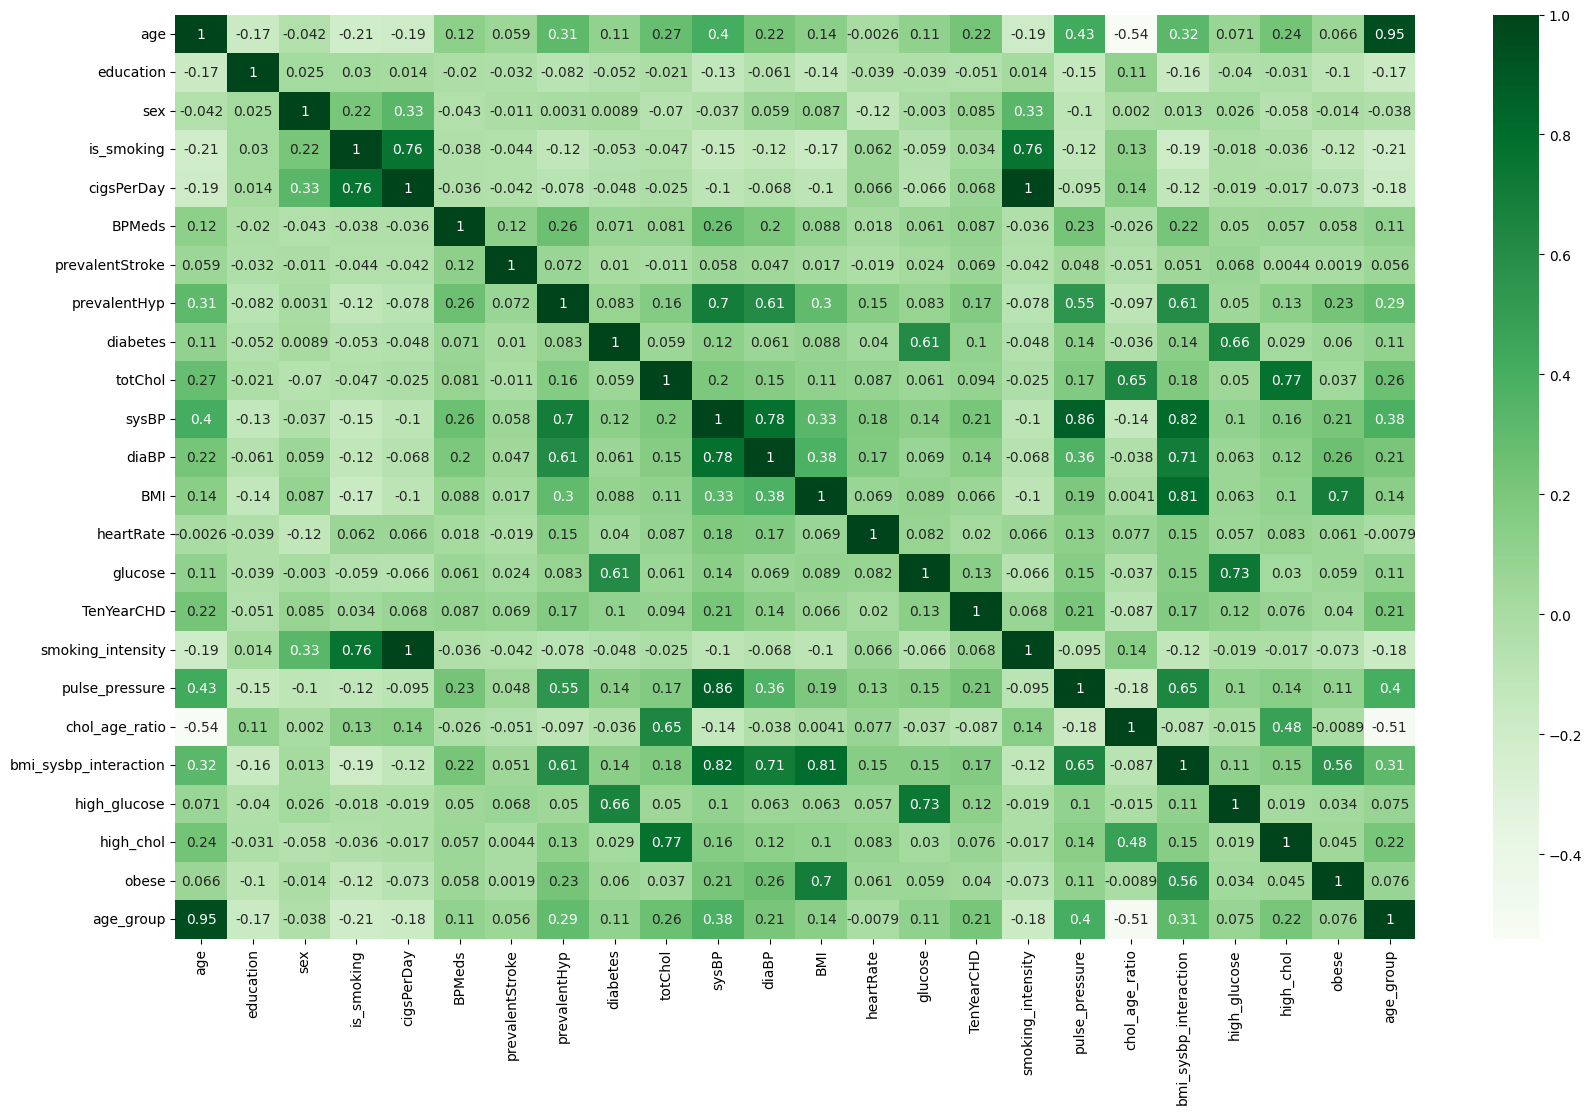

In [77]:
#Correlation matrix
plt.figure(figsize=(20,12))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, cmap='Greens')

<Axes: xlabel='age_group'>

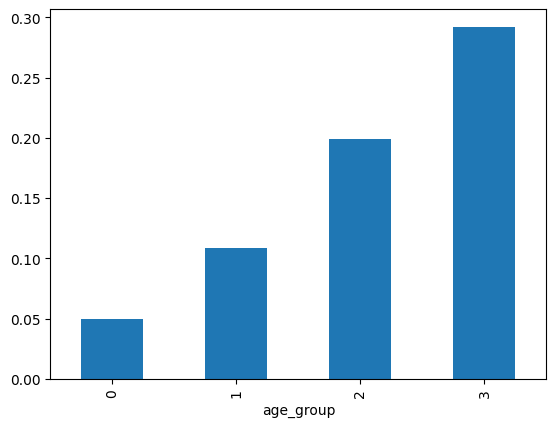

In [78]:
#CHD rate per age group
data.groupby('age_group')['TenYearCHD'].mean().plot(kind='bar')


In [79]:
#drop features that are redundant
data.drop(['cigsPerDay','diaBP','age_group'], axis = 1, inplace = True)

In [80]:
#analysis with high glucose
pd.crosstab(data['high_glucose'], data['TenYearCHD'], normalize='index') * 100


TenYearCHD,0,1
high_glucose,,
0,85.555221,14.444779
1,53.731343,46.268657


In [81]:
#analysis with high chol
pd.crosstab(data['high_chol'], data['TenYearCHD'], normalize='index') * 100


TenYearCHD,0,1
high_chol,,
0,87.268041,12.731959
1,81.793103,18.206897


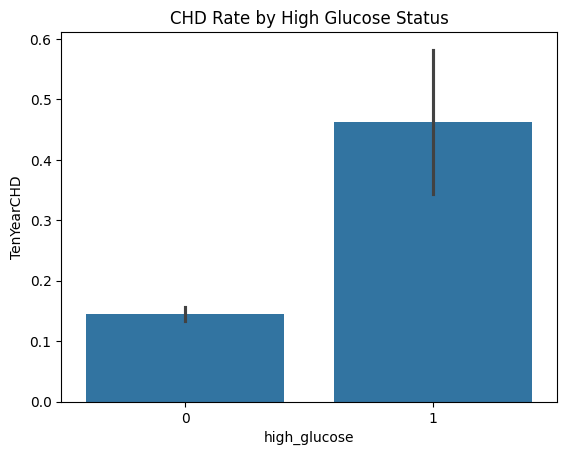

In [82]:
#Plot high glucose vs CHD rate
sns.barplot(x='high_glucose', y='TenYearCHD', data=data)
plt.title('CHD Rate by High Glucose Status')
plt.show()


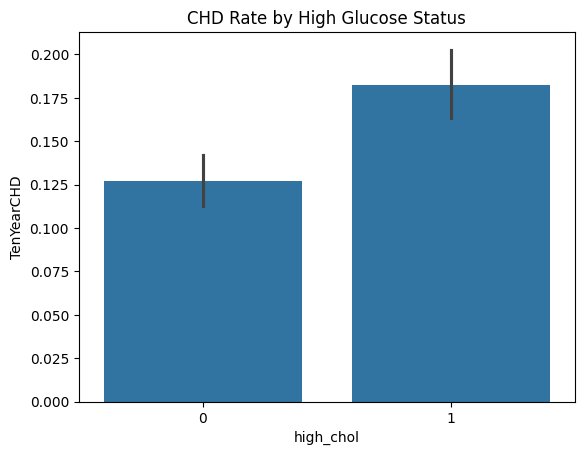

In [83]:
#Plot high chol vs CHD rate
sns.barplot(x='high_chol', y='TenYearCHD', data=data)
plt.title('CHD Rate by High Glucose Status')
plt.show()

In [84]:
#do a chi-squared test to see significance
from scipy.stats import chi2_contingency

table = pd.crosstab(data['high_glucose'], data['TenYearCHD'])
chi2, p, _, _ = chi2_contingency(table)
print(f"p-value: {p}")


p-value: 1.9823760609584714e-12


In [85]:
table = pd.crosstab(data['high_chol'], data['TenYearCHD'])
chi2, p, _, _ = chi2_contingency(table)
print(f"p-value: {p}")

p-value: 1.3042159463366677e-05


In [86]:
data[['high_glucose', 'high_chol', 'TenYearCHD']].corr()

,high_glucose,high_chol,TenYearCHD
high_glucose,1.000000,0.018600,0.123801
high_chol,0.018600,1.000000,0.075706
TenYearCHD,0.123801,0.075706,1.000000


In [87]:
data = pd.get_dummies(data).astype(int)
data.head()

,age,education,sex,is_smoking,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,...,heartRate,glucose,TenYearCHD,smoking_intensity,pulse_pressure,chol_age_ratio,bmi_sysbp_interaction,high_glucose,high_chol,obese
0,64,2,0,1,0,0,0,0,221,148,...,90,80,1,3,63,3,3756,0,0,0
1,36,4,1,0,0,0,1,0,212,168,...,72,75,0,0,70,5,5001,0,0,0
2,46,1,0,1,0,0,0,0,250,116,...,88,94,0,10,45,5,2360,0,1,0
3,50,1,1,1,0,0,1,0,233,158,...,68,94,1,20,70,4,4465,0,0,0
4,64,1,0,1,0,0,0,0,241,136,...,70,77,0,30,51,3,3606,0,1,0


# Model Building

In [88]:
data.shape

(3390, 21)

In [89]:
#Train test split 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,f1_score
#Independent and Dependent features
X = data.drop('TenYearCHD',axis=1)
y = data['TenYearCHD']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

#scale the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape,y_train.shape)
print(X_test_scaled.shape,y_test.shape)

(2712, 20) (2712,)
(678, 20) (678,)


In [90]:
y_test.value_counts()

TenYearCHD
0    574
1    104
Name: count, dtype: int64

## Logistic Regression Model


In [91]:
logit_model = LogisticRegression()
logit_model.fit(X_train_scaled, y_train)
y_pred = logit_model.predict(X_test_scaled)
print(f"Accuracy score on test set: {accuracy_score(y_test,y_pred)}")
print(f"Precision score on test set: {precision_score(y_test,y_pred)}")
print(f"Recall score on test set: {recall_score(y_test,y_pred)}")
print(f"F1 score on test set: {f1_score(y_test,y_pred)}")
print(confusion_matrix(y_test,y_pred))

Accuracy score on test set: 0.8466076696165191
Precision score on test set: 0.5
Recall score on test set: 0.07692307692307693
F1 score on test set: 0.13333333333333333
[[566   8]
 [ 96   8]]


## Logistic Regression Model with SMOTE

In [92]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)
logit_model = LogisticRegression()
logit_model.fit(X_resampled, y_resampled)
y_pred = logit_model.predict(X_test_scaled)
print(f"Accuracy score on test set: {accuracy_score(y_test,y_pred)}")
print(f"Precision score on test set: {precision_score(y_test,y_pred)}")
print(f"Recall score on test set: {recall_score(y_test,y_pred)}")
print(f"F1 score on test set: {f1_score(y_test,y_pred)}")
print(confusion_matrix(y_test,y_pred))

Accuracy score on test set: 0.644542772861357
Precision score on test set: 0.24344569288389514
Recall score on test set: 0.625
F1 score on test set: 0.3504043126684636
[[372 202]
 [ 39  65]]


## Logistic Regression model with UnderSampling

In [93]:
#perform undersampling
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = undersampler.fit_resample(X_train_scaled, y_train)
logit_model = LogisticRegression()
logit_model.fit(X_undersampled, y_undersampled)
y_pred = logit_model.predict(X_test_scaled)
print(f"Accuracy score on test set: {accuracy_score(y_test,y_pred)}")
print(f"Precision score on test set: {precision_score(y_test,y_pred)}")
print(f"Recall score on test set: {recall_score(y_test,y_pred)}")
print(f"F1 score on test set: {f1_score(y_test,y_pred)}")
print(confusion_matrix(y_test,y_pred))


Accuracy score on test set: 0.6342182890855457
Precision score on test set: 0.22932330827067668
Recall score on test set: 0.5865384615384616
F1 score on test set: 0.32972972972972975
[[369 205]
 [ 43  61]]


## Logistic Regression Model with SmoteTomek


In [94]:
#perform combination of undersampling and oversampling
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_sampled, y_sampled = smote_tomek.fit_resample(X_train_scaled, y_train)
logit_model = LogisticRegression()
logit_model.fit(X_sampled, y_sampled)
y_pred = logit_model.predict(X_test_scaled)
print(f"Accuracy score on test set: {accuracy_score(y_test,y_pred)}")
print(f"Precision score on test set: {precision_score(y_test,y_pred)}")
print(f"Recall score on test set: {recall_score(y_test,y_pred)}")
print(f"F1 score on test set: {f1_score(y_test,y_pred)}")
print(confusion_matrix(y_test,y_pred))

Accuracy score on test set: 0.644542772861357
Precision score on test set: 0.24344569288389514
Recall score on test set: 0.625
F1 score on test set: 0.3504043126684636
[[372 202]
 [ 39  65]]


In [95]:
#model training and selection

models = {'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_train,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_train,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_train,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_train,y_train_pred)}")
    print(confusion_matrix(y_train,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')


Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2305    0]
 [   0  407]]


Accuracy score on test set: 0.7433628318584071
Precision score on test set: 0.20833333333333334
Recall score on test set: 0.2403846153846154
F1 score on test set: 0.22321428571428573
[[479  95]
 [ 79  25]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2305    0]
 [   0  407]]


Accuracy score on test set: 0.8451327433628318
Precision score on test set: 0.47058823529411764
Recall score on test set: 0.07692307692307693
F1 score on test set: 0.1322314049586777
[[565   9]
 [ 96   8]]


Model-------------------: Adaboost Classifier


Accuracy score on train set: 0.8561946902654868
Precision score on train set: 0.7575757575757576
Recall score on train set

## ISOLATION FOREST

In [96]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=100, contamination=0.20, max_features=0.8)
iso.fit(X_train,y_train)
y_pred = iso.predict(X_test)
print(y_pred)

[-1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1 -1  1  1  1
  1  1 -1 -1  1  1  1  1 -1 -1 -1  1  1  1 -1 -1 -1  1  1  1  1  1 -1  1
  1  1  1 -1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1 -1 -1 -1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1
 -1 -1  1  1  1  1  1 -1  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1 -1
 -1  1  1  1  1 -1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1  1 -1  1  1 -1
  1  1  1  1 -1  1  1  1  1 -1 -1 -1  1  1  1  1  1  1  1  1 -1  1  1  1
  1  1 -1  1  1  1  1 -1  1 -1  1  1  1 -1  1  1 -1  1  1  1  1 -1  1  1
  1  1  1 -1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1 -1  1
  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1 -1  1 -1  1  1  1  1 -1  1  1
  1  1  1 -1  1  1  1  1 -1 -1  1 -1  1  1  1  1  1  1 -1  1  1 -1  1  1
 -1  1 -1 -1  1  1  1  1  1  1  1  1  1 -1 -1  1  1

In [97]:
#performance on training test
y_pred_train = iso.predict(X_train)
y_pred_train = np.where(y_pred_train == -1, 1, 0)
print(f"Accuracy score on test set: {accuracy_score(y_train,y_pred_train)}")
print(f"Precision score on test set: {precision_score(y_train,y_pred_train)}")
print(f"Recall score on test set: {recall_score(y_train,y_pred_train)}")
print(f"F1 score on test set: {f1_score(y_train,y_pred_train)}")
print(confusion_matrix(y_train,y_pred_train))


Accuracy score on test set: 0.7573746312684366
Precision score on test set: 0.26887661141804786
Recall score on test set: 0.35872235872235875
F1 score on test set: 0.30736842105263157
[[1908  397]
 [ 261  146]]


In [98]:
y_pred = np.where(y_pred == -1, 1, 0)
print(y_pred)

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0
 0 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0
 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1
 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1
 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 0 1 0 0 0 0 0 0 0 

In [99]:
print(f"Accuracy score on test set: {accuracy_score(y_test,y_pred)}")
print(f"Precision score on test set: {precision_score(y_test,y_pred)}")
print(f"Recall score on test set: {recall_score(y_test,y_pred)}")
print(f"F1 score on test set: {f1_score(y_test,y_pred)}")
print(confusion_matrix(y_test,y_pred))


Accuracy score on test set: 0.7595870206489675
Precision score on test set: 0.304635761589404
Recall score on test set: 0.4423076923076923
F1 score on test set: 0.3607843137254902
[[469 105]
 [ 58  46]]


# Oversampling using SMOTE

In [100]:
#perform oversampling using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


In [101]:
X_resampled.shape, y_resampled.shape

((4610, 20), (4610,))

In [102]:
#target class is balanced after applying SMOTE technique
y_resampled.value_counts()

TenYearCHD
0    2305
1    2305
Name: count, dtype: int64

In [103]:
models = {'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_resampled,y_resampled)
    y_train_pred = model.predict(X_resampled)
    y_test_pred = model.predict(X_test)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_resampled,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_resampled,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_resampled,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_resampled,y_train_pred)}")
    print(confusion_matrix(y_resampled,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')

Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2305    0]
 [   0 2305]]


Accuracy score on test set: 0.696165191740413
Precision score on test set: 0.18125
Recall score on test set: 0.27884615384615385
F1 score on test set: 0.2196969696969697
[[443 131]
 [ 75  29]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2305    0]
 [   0 2305]]


Accuracy score on test set: 0.7669616519174042
Precision score on test set: 0.21875
Recall score on test set: 0.20192307692307693
F1 score on test set: 0.21
[[499  75]
 [ 83  21]]


Model-------------------: Adaboost Classifier


Accuracy score on train set: 0.7683297180043384
Precision score on train set: 0.7711530030688295
Recall score on train set: 0.7631236442516269
F1 score on train 

# Undersampling

In [104]:
#perform undersampling
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = undersampler.fit_resample(X_train, y_train)

In [105]:
X_undersampled.shape,y_undersampled.shape

((814, 20), (814,))

In [106]:
y_undersampled.value_counts()

TenYearCHD
0    407
1    407
Name: count, dtype: int64

In [107]:
models = {'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_undersampled,y_undersampled)
    y_train_pred = model.predict(X_undersampled)
    y_test_pred = model.predict(X_test)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_undersampled,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_undersampled,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_undersampled,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_undersampled,y_train_pred)}")
    print(confusion_matrix(y_undersampled,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')

Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[407   0]
 [  0 407]]


Accuracy score on test set: 0.556047197640118
Precision score on test set: 0.1853035143769968
Recall score on test set: 0.5576923076923077
F1 score on test set: 0.27817745803357313
[[319 255]
 [ 46  58]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[407   0]
 [  0 407]]


Accuracy score on test set: 0.6710914454277286
Precision score on test set: 0.26294820717131473
Recall score on test set: 0.6346153846153846
F1 score on test set: 0.37183098591549296
[[389 185]
 [ 38  66]]


Model-------------------: Adaboost Classifier


Accuracy score on train set: 0.6769041769041769
Precision score on train set: 0.6614349775784754
Recall score on train set: 0.724815

We can observe that after applying undersampling all the models perform reasonably better than the base models with Random Forest model performing the best. We can also observe the boosting models performing better than the base boosting models as well as the boosting models where oversampling using SMOTE was used.

# Oversampling using SMOTE TOMEK

In [108]:
#perform combination of undersampling and oversampling
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_sampled, y_sampled = smote_tomek.fit_resample(X_train, y_train)

In [109]:
X_sampled.shape,y_sampled.shape

((4498, 20), (4498,))

In [110]:
y_sampled.value_counts()

TenYearCHD
0    2249
1    2249
Name: count, dtype: int64

In [111]:
models = {'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_sampled,y_sampled)
    y_train_pred = model.predict(X_sampled)
    y_test_pred = model.predict(X_test)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_sampled,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_sampled,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_sampled,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_sampled,y_train_pred)}")
    print(confusion_matrix(y_sampled,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')

Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2249    0]
 [   0 2249]]


Accuracy score on test set: 0.6843657817109144
Precision score on test set: 0.1686746987951807
Recall score on test set: 0.2692307692307692
F1 score on test set: 0.2074074074074074
[[436 138]
 [ 76  28]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2249    0]
 [   0 2249]]


Accuracy score on test set: 0.7669616519174042
Precision score on test set: 0.21875
Recall score on test set: 0.20192307692307693
F1 score on test set: 0.21
[[499  75]
 [ 83  21]]


Model-------------------: Adaboost Classifier


Accuracy score on train set: 0.7670075589150733
Precision score on train set: 0.7691618108471537
Recall score on train set: 0.7630057803468208
F1 scor

After using both the oversampling and undersampling techniques such as SMOTE, Undersampling and SMOTE TOMEK, we found the Random Forest model using SMOTE TOMEK to be the best performing with 71/104 instances of the minority class predicted correctly on the test data. Hence, we will apply hyperparameter tuning on this model to further reduce the amount of false negatives, which in turn will improve the recall score of the minority class.

In [112]:
from sklearn.calibration import CalibratedClassifierCV
# Calibrated AdaBoost with class_weight
base_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=42)
calibrated_model = CalibratedClassifierCV(base_model, cv=3)
calibrated_model.fit(X_undersampled, y_undersampled)

# Predict probabilities
probas = calibrated_model.predict_proba(X_test)[:, 1]

# Threshold tuning
thresholds = np.arange(0.1, 0.6, 0.05)
for t in thresholds:
    y_pred_thresh = (probas >= t).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold {t:.2f} — Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

Threshold 0.10 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.15 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.20 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.25 — Precision: 0.155, Recall: 1.000, F1: 0.268
Threshold 0.30 — Precision: 0.165, Recall: 0.962, F1: 0.282
Threshold 0.35 — Precision: 0.186, Recall: 0.894, F1: 0.308
Threshold 0.40 — Precision: 0.204, Recall: 0.798, F1: 0.325
Threshold 0.45 — Precision: 0.222, Recall: 0.712, F1: 0.339
Threshold 0.50 — Precision: 0.232, Recall: 0.577, F1: 0.331
Threshold 0.55 — Precision: 0.274, Recall: 0.529, F1: 0.361


In [113]:
!pip install catboost

  Using cached catboost-1.2.8-cp310-cp310-macosx_11_0_universal2.whl (27.8 MB)
  Using cached graphviz-0.21-py3-none-any.whl (47 kB)
  Using cached plotly-6.1.2-py3-none-any.whl (16.3 MB)
  Using cached narwhals-1.43.0-py3-none-any.whl (362 kB)

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [114]:
from catboost import CatBoostClassifier
# Define and train CatBoost
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='Recall',
    auto_class_weights='Balanced',  # Helps with class imbalance
    random_state=42,
    verbose=100
)

# You can pass categorical features by index if not one-hot encoded
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

# Predict probabilities
probas = cat_model.predict_proba(X_test)[:, 1]

# Threshold tuning
thresholds = np.arange(0.1, 0.6, 0.05)
for t in thresholds:
    y_pred_thresh = (probas >= t).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold {t:.2f} — Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

0:	learn: 0.6240786	test: 0.6057692	best: 0.6057692 (0)	total: 58.5ms	remaining: 58.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7019230769
bestIteration = 1

Shrink model to first 2 iterations.
Threshold 0.10 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.15 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.20 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.25 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.30 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.35 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.40 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.45 — Precision: 0.155, Recall: 1.000, F1: 0.268
Threshold 0.50 — Precision: 0.246, Recall: 0.702, F1: 0.364
Threshold 0.55 — Precision: 0.333, Recall: 0.010, F1: 0.019


# Hyperparameter Tuning 

In [115]:
from sklearn.model_selection import GridSearchCV
catboost_model = CatBoostClassifier(
    loss_function='Logloss',
    auto_class_weights='Balanced',  # handles imbalance
    eval_metric='Recall',
    random_seed=42,
    verbose=0
)

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200],  # fixed high value for early stopping
}

grid = GridSearchCV(estimator=catboost_model, param_grid=param_grid, scoring='recall', cv=3)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_

probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.6, 0.05)
for t in thresholds:
    y_pred = (probs >= t).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Threshold {t:.2f} — Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")


Best parameters: {'depth': 4, 'iterations': 200, 'learning_rate': 0.01}
Threshold 0.10 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.15 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.20 — Precision: 0.153, Recall: 1.000, F1: 0.266
Threshold 0.25 — Precision: 0.157, Recall: 1.000, F1: 0.272
Threshold 0.30 — Precision: 0.171, Recall: 0.971, F1: 0.291
Threshold 0.35 — Precision: 0.194, Recall: 0.933, F1: 0.322
Threshold 0.40 — Precision: 0.202, Recall: 0.817, F1: 0.324
Threshold 0.45 — Precision: 0.211, Recall: 0.702, F1: 0.324
Threshold 0.50 — Precision: 0.237, Recall: 0.635, F1: 0.345
Threshold 0.55 — Precision: 0.274, Recall: 0.519, F1: 0.359


# Feature Importances

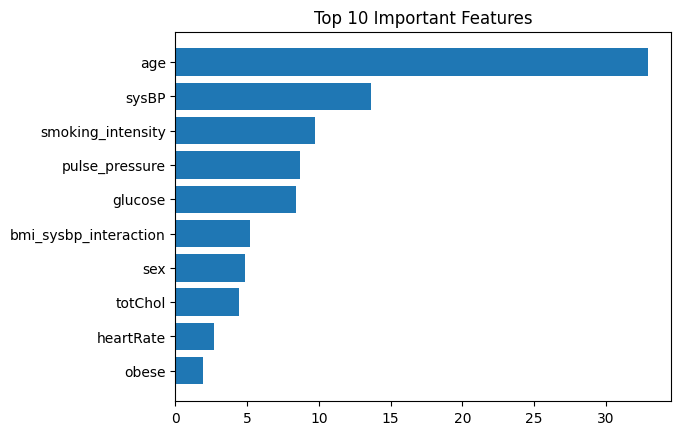

In [116]:
feature_importances = best_model.get_feature_importance()
feature_names = X.columns

# Plot top 10
sorted_idx = np.argsort(feature_importances)[::-1]
top_n = 10
plt.barh(range(top_n), feature_importances[sorted_idx][:top_n])
plt.yticks(range(top_n), [feature_names[i] for i in sorted_idx[:top_n]])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


## Save Model and threshold for Adaboost Classifier (modelv1)

Confusion Matrix (AdaBoost @ Threshold 0.45):
              precision    recall  f1-score   support

           0       0.91      0.48      0.63       574
           1       0.20      0.73      0.32       104

    accuracy                           0.52       678
   macro avg       0.55      0.60      0.47       678
weighted avg       0.80      0.52      0.58       678



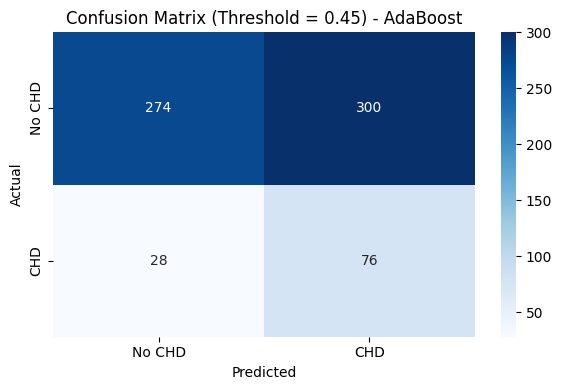

In [117]:
modelv1 = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=42)
modelv1.fit(X_undersampled, y_undersampled)

# Predict probabilities on test set
probas = modelv1.predict_proba(X_test)[:, 1]
y_pred_thresh = (probas >= 0.45).astype(int)
threshold = 0.45
# Confusion Matrix and Classification Report
print("Confusion Matrix (AdaBoost @ Threshold 0.45):")
print(classification_report(y_test, y_pred_thresh))
cm = confusion_matrix(y_test, y_pred_thresh)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {threshold}) - AdaBoost')
plt.tight_layout()
plt.show()

In [118]:
import joblib

# Save the model as a .pkl file
joblib.dump(modelv1, 'modelv1.joblib')


['modelv1.joblib']

## Save Model and Threshold for Catboost Classifier (modelv2)

Confusion Matrix (CatBoost @ Threshold 0.40):
              precision    recall  f1-score   support

           0       0.93      0.41      0.57       574
           1       0.20      0.82      0.32       104

    accuracy                           0.48       678
   macro avg       0.56      0.62      0.45       678
weighted avg       0.81      0.48      0.53       678



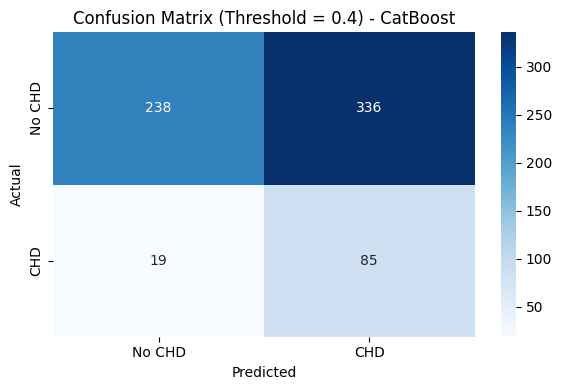

In [119]:
# Predict probabilities on test set
probas = best_model.predict_proba(X_test)[:, 1]
y_pred_thresh = (probas >= 0.40).astype(int)
threshold = 0.40

# Confusion Matrix and Classification Report
print("Confusion Matrix (CatBoost @ Threshold 0.40):")
print(classification_report(y_test, y_pred_thresh))
cm = confusion_matrix(y_test, y_pred_thresh)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {threshold}) - CatBoost')
plt.tight_layout()
plt.show()

In [121]:
import joblib

# Save model
joblib.dump(best_model, 'modelv2.joblib')
# Save threshold separately
with open('adaboost_threshold.txt', 'w') as f:
    f.write(str(0.45))
with open('catboost_threshold.txt', 'w') as f:
    f.write(str(0.40))


In [128]:
import joblib

feature_list = X_undersampled.columns.tolist()
joblib.dump(feature_list, 'modelv1_features.joblib')


['modelv1_features.joblib']

In [129]:
feature_list = X_train.columns.tolist()
joblib.dump(feature_list, 'modelv2_features.joblib')


['modelv2_features.joblib']

In [124]:
!which python

/Users/kumarbaibhav/Downloads/Cardiovascular-Risk-Prediction_/cardio-api/venv/bin/python


In [125]:
!python3 --version

Python 3.10.15
